In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("D:/pycharm/fastapi/data/stud.csv")

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## EDA and Pre Processing

In [10]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


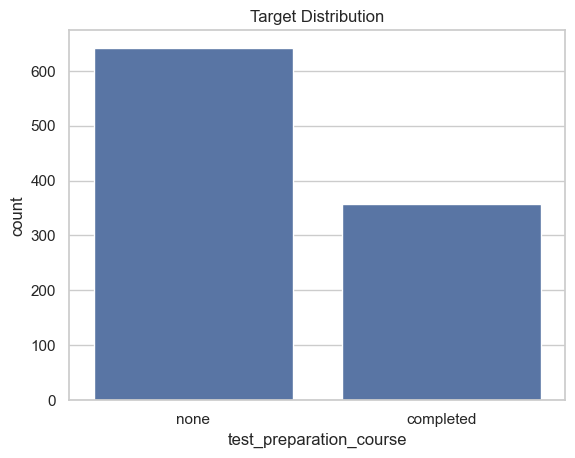

In [15]:
sns.countplot(x="test_preparation_course", data=df)
plt.title("Target Distribution")
plt.show()

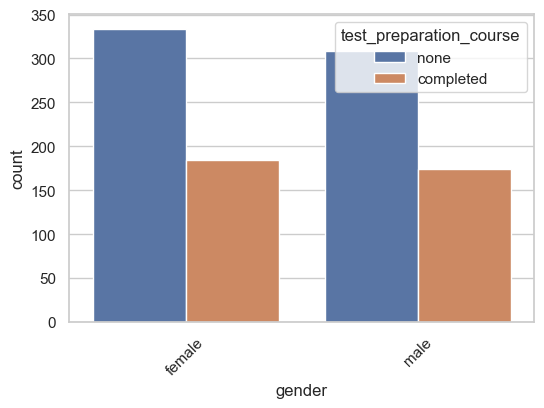

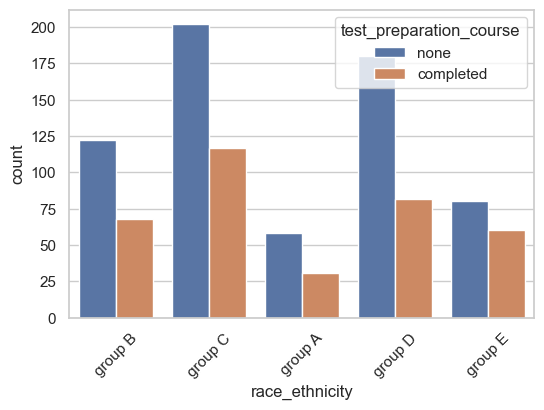

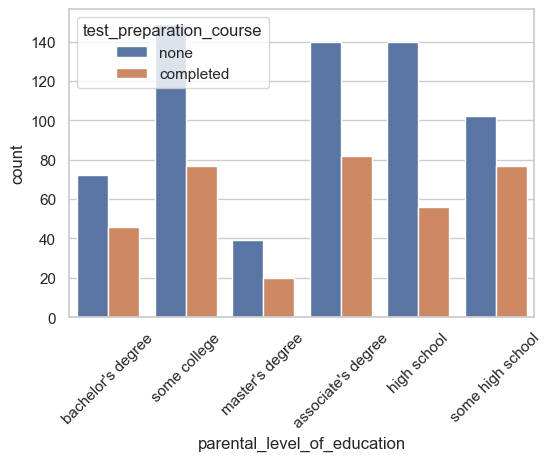

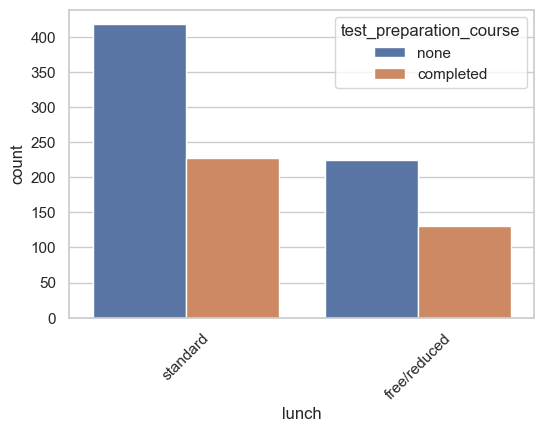

In [16]:
categorical_cols = ["gender", "race_ethnicity",
                    "parental_level_of_education", "lunch"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="test_preparation_course", data=df)
    plt.xticks(rotation=45)
    plt.show()

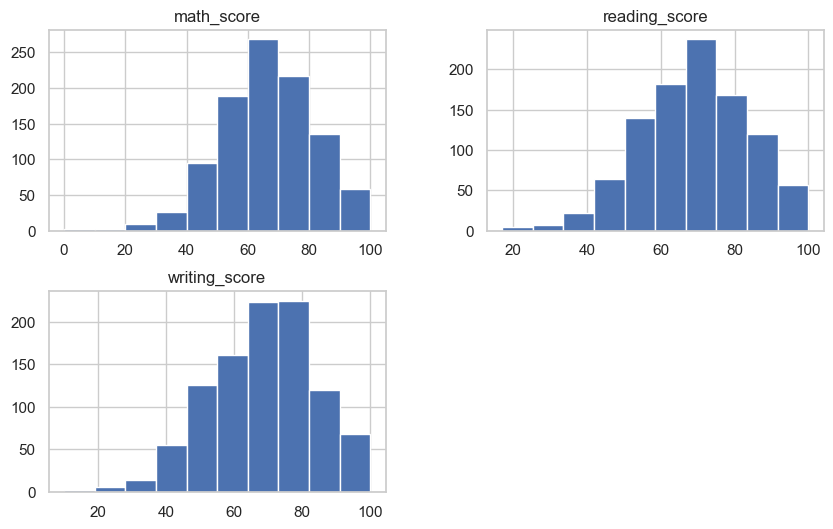

In [17]:
numerical_cols = ["math_score", "reading_score", "writing_score"]

df[numerical_cols].hist(figsize=(10,6))
plt.show()

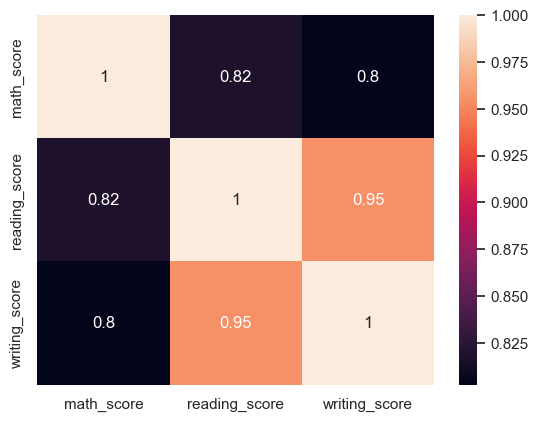

In [18]:
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.show()

In [19]:
from scipy.stats import ttest_ind

completed = df[df["test_preparation_course"]=="completed"]["math_score"]
not_completed = df[df["test_preparation_course"]=="none"]["math_score"]

ttest_ind(completed, not_completed)

TtestResult(statistic=np.float64(5.704616417349102), pvalue=np.float64(1.5359134607147448e-08), df=np.float64(998.0))

In [20]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["gender"], df["test_preparation_course"])
chi2_contingency(contingency)

Chi2ContingencyResult(statistic=np.float64(0.015529201882465888), pvalue=np.float64(0.9008273880804724), dof=1, expected_freq=array([[185.444, 332.556],
       [172.556, 309.444]]))

In [30]:
#Gender does not show statistical significance with course completion (p=0.90),
#whereas math scores show strong significance (p<0.001), indicating academic
#performance is closely associated with course completion.

Model Training

In [25]:
categorical_cols = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch"
]

numerical_cols = [
    "math_score",
    "reading_score",
    "writing_score"
]

# -----------------------------
# Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [35]:
models = {
"LogisticRegression": LogisticRegression(max_iter=1000,class_weight="balanced"),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier()
}
# Define Features & Target
# -----------------------------
X = df.drop("test_preparation_course", axis=1)
y = df["test_preparation_course"]

results = {}
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label="completed")

    results[name] = {"Accuracy": acc, "F1": f1}

results

{'LogisticRegression': {'Accuracy': 0.71, 'F1': 0.6506024096385542},
 'RandomForest': {'Accuracy': 0.645, 'F1': 0.42276422764227645},
 'GradientBoosting': {'Accuracy': 0.665, 'F1': 0.464}}

In [37]:
print(pipe.classes_)

['completed' 'none']


In [42]:
proba = pipe.predict_proba(X_test)

completed_index = list(pipe.classes_).index("completed")
y_proba = proba[:, completed_index]

roc_auc = roc_auc_score(
    (y_test == "completed").astype(int),
    y_proba
)

print("ROC-AUC:", roc_auc)

print(classification_report(y_test, y_pred))

ROC-AUC: 0.751804582069254
              precision    recall  f1-score   support

   completed       0.63      0.37      0.46        79
        none       0.68      0.86      0.76       121

    accuracy                           0.67       200
   macro avg       0.65      0.61      0.61       200
weighted avg       0.66      0.67      0.64       200



In [43]:
from sklearn.metrics import roc_curve
import numpy as np

# Convert y_test to binary (1 = completed)
y_true = (y_test == "completed").astype(int)

# Get probability for completed class
proba = pipe.predict_proba(X_test)
completed_index = list(pipe.classes_).index("completed")
y_proba = proba[:, completed_index]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)

# Compute Youden’s J statistic
j_scores = tpr - fpr

# Find best threshold
optimal_index = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_index]

print("Optimal Threshold (ROC-based):", optimal_threshold)

Optimal Threshold (ROC-based): 0.34326226254847747


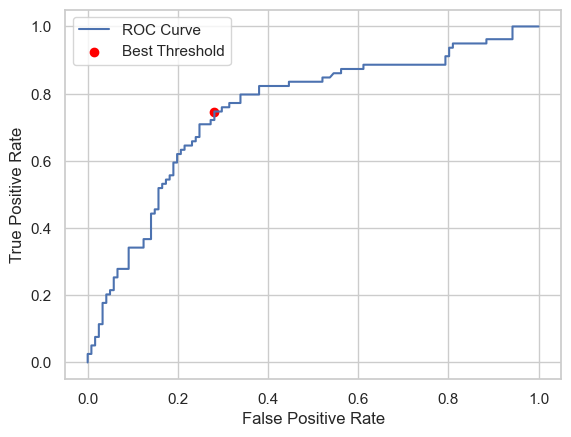

In [44]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[optimal_index], tpr[optimal_index], color='red', label="Best Threshold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [45]:
y_pred_custom = (y_proba >= optimal_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_custom))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76       121
           1       0.63      0.75      0.69        79

    accuracy                           0.73       200
   macro avg       0.72      0.73      0.72       200
weighted avg       0.74      0.73      0.73       200



In [28]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Student_Performance_EDA_Modeling")

2026/03/03 17:14:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/03 17:14:37 INFO mlflow.store.db.utils: Updating database tables
2026/03/03 17:14:39 INFO mlflow.tracking.fluent: Experiment with name 'Student_Performance_EDA_Modeling' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:D:/pycharm/fastapi/notebook/mlruns/1', creation_time=1772538279039, experiment_id='1', last_update_time=1772538279039, lifecycle_stage='active', name='Student_Performance_EDA_Modeling', tags={}, workspace='default'>

In [29]:
with mlflow.start_run(run_name=name):

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label="completed")

    mlflow.log_param("model", name)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(pipe, name)

2026/03/03 17:14:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 17:14:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
